# Feature Engineering

### Handling missing datas

In [6]:
import pandas as pd
import numpy as np

In [15]:
df = pd.read_csv("titanic.csv")
df=df.sample(5)
print("Original DataFrame with Missing Values:")
print(df)

Original DataFrame with Missing Values:
     PassengerId  Survived  Pclass                               Name     Sex  \
234          235         0       2  Leyson, Mr. Robert William Norman    male   
627          628         1       1      Longley, Miss. Gretchen Fiske  female   
487          488         0       1            Kent, Mr. Edward Austin    male   
318          319         1       1           Wick, Miss. Mary Natalie  female   
80            81         0       3               Waelens, Mr. Achille    male   

      Age  SibSp  Parch      Ticket      Fare Cabin Embarked  
234  24.0      0      0  C.A. 29566   10.5000   NaN        S  
627  21.0      0      0       13502   77.9583    D9        S  
487  58.0      0      0       11771   29.7000   B37        C  
318  31.0      0      2       36928  164.8667    C7        S  
80   22.0      0      0      345767    9.0000   NaN        S  


In [16]:
print(df.isnull().sum()) 

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          2
Embarked       0
dtype: int64


In [17]:
df_dropped_rows = df.dropna()
print("\nDataFrame after dropping rows with missing values:")
print(df_dropped_rows)


DataFrame after dropping rows with missing values:
     PassengerId  Survived  Pclass                           Name     Sex  \
627          628         1       1  Longley, Miss. Gretchen Fiske  female   
487          488         0       1        Kent, Mr. Edward Austin    male   
318          319         1       1       Wick, Miss. Mary Natalie  female   

      Age  SibSp  Parch Ticket      Fare Cabin Embarked  
627  21.0      0      0  13502   77.9583    D9        S  
487  58.0      0      0  11771   29.7000   B37        C  
318  31.0      0      2  36928  164.8667    C7        S  


### Handling categorical value

In [9]:
df = pd.read_csv("titanic.csv")
df=df.sample(5)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])  # Most frequent value
print(df)

     PassengerId  Survived  Pclass                          Name     Sex  \
330          331         1       3            McCoy, Miss. Agnes  female   
671          672         0       1        Davidson, Mr. Thornton    male   
817          818         0       2            Mallet, Mr. Albert    male   
515          516         0       1  Walker, Mr. William Anderson    male   
819          820         0       3  Skoog, Master. Karl Thorsten    male   

      Age  SibSp  Parch           Ticket     Fare Cabin Embarked  
330   NaN      2      0           367226  23.2500   NaN        Q  
671  31.0      1      0       F.C. 12750  52.0000   B71        S  
817  31.0      1      1  S.C./PARIS 2079  37.0042   NaN        C  
515  47.0      0      0            36967  34.0208   D46        S  
819  10.0      3      2           347088  27.9000   NaN        S  


In [10]:
# Label Encoding  vs ordinal Encoding 

from sklearn.preprocessing import LabelEncoder
 
# Apply Label Encoding to 'Size'
label_encoder = LabelEncoder()
df['Embarked'] = label_encoder.fit_transform(df['Embarked'])

print("\nDataFrame after Label Encoding for 'Embarked':\n", df)


DataFrame after Label Encoding for 'Embarked':
      PassengerId  Survived  Pclass                          Name     Sex  \
330          331         1       3            McCoy, Miss. Agnes  female   
671          672         0       1        Davidson, Mr. Thornton    male   
817          818         0       2            Mallet, Mr. Albert    male   
515          516         0       1  Walker, Mr. William Anderson    male   
819          820         0       3  Skoog, Master. Karl Thorsten    male   

      Age  SibSp  Parch           Ticket     Fare Cabin  Embarked  
330   NaN      2      0           367226  23.2500   NaN         1  
671  31.0      1      0       F.C. 12750  52.0000   B71         2  
817  31.0      1      1  S.C./PARIS 2079  37.0042   NaN         0  
515  47.0      0      0            36967  34.0208   D46         2  
819  10.0      3      2           347088  27.9000   NaN         2  


### Scaling the features

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler

#  Load dataset
df = pd.read_csv("titanic.csv")
df=df.head(6)
print("Original Data:\n", df.head())

#  Select numerical features
numerical_features = df.select_dtypes(include=[np.number]).columns

#  Initialize scalers
standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()
robust_scaler = RobustScaler()
maxabs_scaler = MaxAbsScaler()

#  Apply Standard Scaler
df_standard = df.copy()
df_standard[numerical_features] = standard_scaler.fit_transform(df[numerical_features])

#  Apply MinMax Scaler
df_minmax = df.copy()
df_minmax[numerical_features] = minmax_scaler.fit_transform(df[numerical_features])

#  Apply Robust Scaler (good for outliers)
df_robust = df.copy()
df_robust[numerical_features] = robust_scaler.fit_transform(df[numerical_features])

#  Apply MaxAbs Scaler (works well with sparse data)
df_maxabs = df.copy()
df_maxabs[numerical_features] = maxabs_scaler.fit_transform(df[numerical_features])

#  Log Transformation
df_log = df.copy()
# Shift data if there are negative values
if (df_log[numerical_features] < 0).any().any():
    df_log[numerical_features] = np.log1p(df_log[numerical_features] - df_log[numerical_features].min() + 1)
else:
    df_log[numerical_features] = np.log1p(df_log[numerical_features])

#  Display results
print("\nStandard Scaled:\n", df_standard.head())
print("\nMinMax Scaled:\n", df_minmax.head())
print("\nRobust Scaled:\n", df_robust.head())
print("\nMaxAbs Scaled:\n", df_maxabs.head())
print("\nLog Transformed:\n", df_log.head())

Original Data:
    PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   N

#### Note: df.copy() is used to create a separate copy of the original data. When different scaling methods are applied, the original dataset remains unchanged, allowing us to compare the results of different scalings without losing the original data. It can be done without df.copy(), but then there is a risk of overwriting the original dataset and mixing up the results.

### Removing Outliers

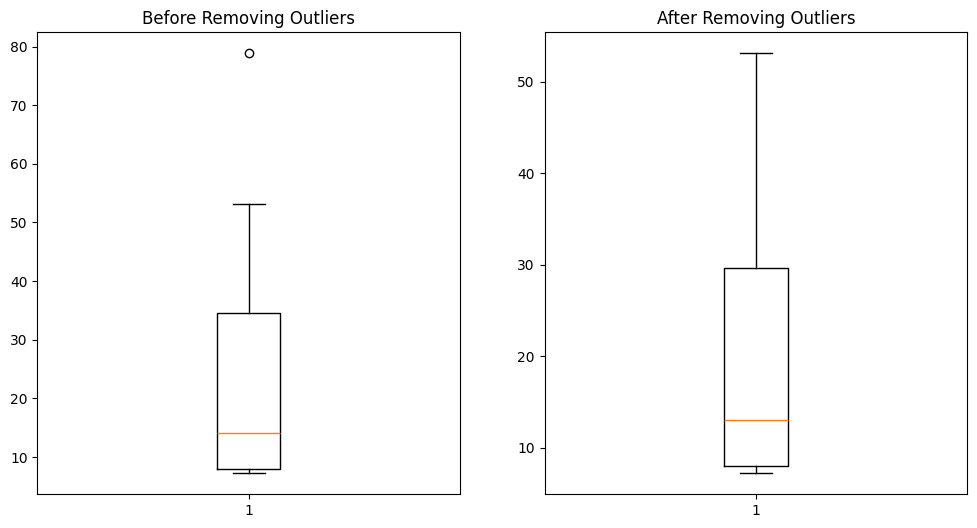

Data after removing outliers:
     PassengerId  Survived  Pclass  \
709          710         1       3   
439          440         0       2   
840          841         0       3   
720          721         1       2   
39            40         1       3   

                                                  Name     Sex   Age  SibSp  \
709  Moubarek, Master. Halim Gonios ("William George")    male   NaN      1   
439             Kvillner, Mr. Johan Henrik Johannesson    male  31.0      0   
840                        Alhomaki, Mr. Ilmari Rudolf    male  20.0      0   
720                  Harper, Miss. Annie Jessie "Nina"  female   6.0      0   
39                         Nicola-Yarred, Miss. Jamila  female  14.0      1   

     Parch            Ticket     Fare Cabin Embarked  
709      1              2661  15.2458   NaN        C  
439      0        C.A. 18723  10.5000   NaN        S  
840      0  SOTON/O2 3101287   7.9250   NaN        S  
720      1            248727  33.0000   NaN   

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load Titanic dataset
df = pd.read_csv("titanic.csv")

# Generate random 20 rows
np.random.seed(42)
df_sample = df.sample(n=20, random_state=42)

# Use Fare column for outlier detection
data = df_sample['Fare'].dropna()

# Calculate Q1, Q3, and IQR
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove outliers
df_filtered = df_sample[
    (df_sample['Fare'] >= lower_bound) & 
    (df_sample['Fare'] <= upper_bound)
]

# Plot before and after removing outliers
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.boxplot(df_sample['Fare'].dropna())
ax1.set_title("Before Removing Outliers")

ax2.boxplot(df_filtered['Fare'].dropna())
ax2.set_title("After Removing Outliers")

plt.show()

print("Data after removing outliers:")
print(df_filtered.head())

### Feature Selection

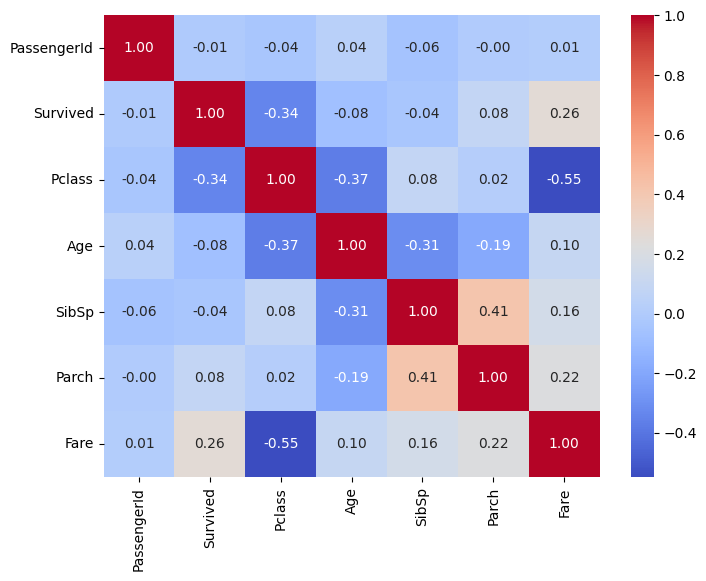

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("titanic.csv")
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Calculate correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap of correlation matrix
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

# Drop highly correlated features (e.g., correlation > 0.9)
corr_threshold = 0.9
to_drop = [column for column in upper.columns
           if any(abs(upper[column]) > corr_threshold)]


### PCA 

In [31]:
import pandas as pd

# Load the dataset
df = pd.read_csv("titanic.csv")  # Replace with actual dataset path
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [32]:
from sklearn.preprocessing import StandardScaler

# Selecting numerical features
numerical_features = df.select_dtypes(include=['float64', 'int64']).drop(columns=['median_house_value'], errors='ignore')  # Drop target if applicable

# Standardizing the features
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numerical_features)

In [33]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")  # You can also use "median" or "most_frequent"
scaled_data = imputer.fit_transform(scaled_data)


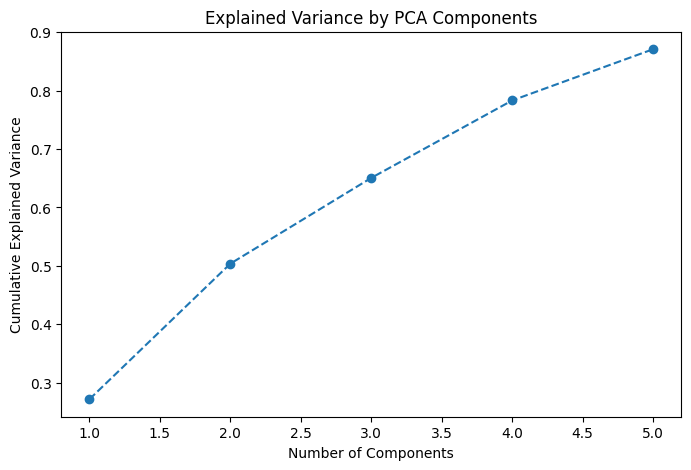

In [34]:

# manually 
from sklearn.decomposition import PCA

# Choose the number of components
pca = PCA(n_components=5)  # Adjust based on variance explained
pca_features = pca.fit_transform(scaled_data)

# Convert to DataFrame
pca_df = pd.DataFrame(pca_features, columns=[f'PC{i+1}' for i in range(5)])


import matplotlib.pyplot as plt

explained_variance = pca.explained_variance_ratio_

# Plot cumulative variance
plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_variance)+1), explained_variance.cumsum(), marker='o', linestyle='--')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance by PCA Components")
plt.show()

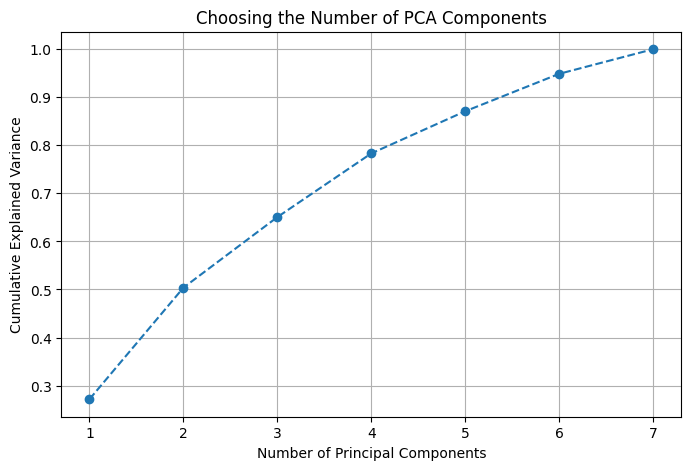

In [35]:

# automate the n component

from sklearn.decomposition import PCA
import numpy as np

# Apply PCA without specifying components (to analyze all)
pca = PCA()
pca.fit(scaled_data)

# Calculate cumulative variance explained
explained_variance = np.cumsum(pca.explained_variance_ratio_)

# Plot the explained variance
plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='--')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Choosing the Number of PCA Components")
plt.grid()
plt.show()